# НИС «Основы анализа данных в Python»

*Алла Тамбовцева*

## Теория к лабораторной работе 7

* Матрица диаграмм рассеивания
* Корреляционная матрица и тепловая карта
* Коэффициенты корреляции и проверка гипотез
* Критерий хи-квадрат и тепловая карта

Импортируем библиотеку `pandas` и загрузим данные о пингвинах, которые используются в примерах в документации к графической библиотеке `seaborn`:

In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/refs/heads/master/penguins.csv"
pen = pd.read_csv(url)
pen.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


### Матрица диаграмм рассеивания

Предположим, мы хотим осуществить разведывательный анализ данных и оценить связи между всеми числовыми показателями в `df`. Чтобы выбрать все числовые столбцы, можно воспользоваться методом `.select_dtypes()` и указать в качестве аргумента перечень подходящих типов:

In [3]:
# числовые: float + int, 
# правда, здесь в данных только float

pen_num = pen.select_dtypes([float, int])
pen_num.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0


Построим **матрицу диаграмм рассеивания** для всех пар показателей в `pen_num`:

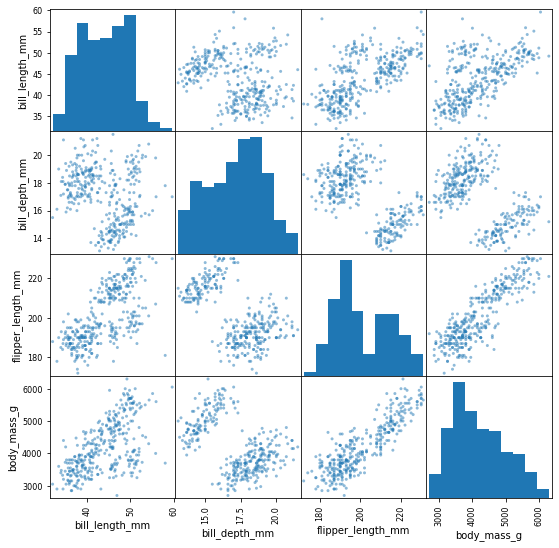

In [4]:
# размер графика 9 на 9 дюймов

pd.plotting.scatter_matrix(pen_num, 
                           figsize = (9, 9));

На главной диагонали этой матрицы – гистограммы для всех столбцов в `pen_num` (так как строить диаграмму рассеивания для показателя самим с собой бессмысленно, можно вместо этого визуализировать его распределение). Соответственно, здесь это `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

В остальных ячейках построены диаграммы рассеивания, причем графики под главной диагональю и симметричные им графики над главной диагональю содержательно одинаковы – это диаграммы рассеивания для одних и тех же показателей, просто горизонтальная и вертикальная оси поменяны местами.

Так, график на пересечении второй строки и первого столбца – диаграмма рассеивания для столбцов `bill_lengtn_mm` (горизонтальная ось) и `bill_depth_mm` (вертикальная ось), а график на пересечении первой строки и второго столбца – диаграмма рассеивания для `bill_depth_mm` (горизонтальная ось) и `bill_lengtn_mm` (вертикальная ось).

Так как этот график – в первую очередь матрица *диаграмм рассеивания*, основные стилевые настройки относятся к точкам на этих диаграммах. Так, если мы добавим аргументы `color` (цвет) и `alpha` (непрозрачность), они будут относиться исключительно к точкам и не будут затрагивать стиль гистограмм. Для изменения параметров гистограмм нужно задействовать аргумент `hist_kwds` (от *histogram keywords*) и записать все параметры в виде словаря:

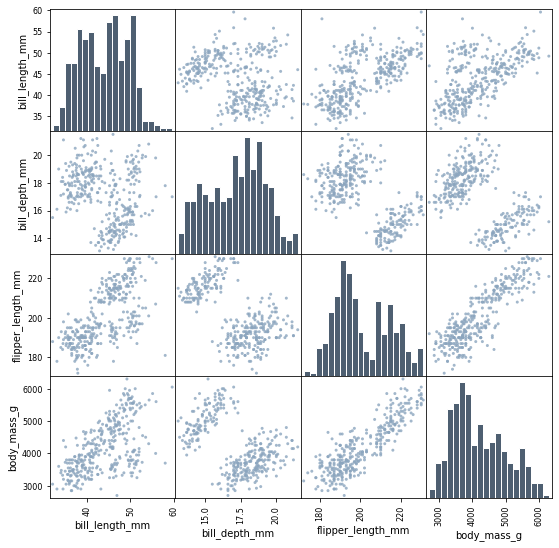

In [5]:
# bins – число столбцов

pd.plotting.scatter_matrix(pen_num, 
                           figsize = (9, 9),
                           color = "#8ba5be", 
                           alpha = 0.8,
                           hist_kwds = {"color" : "#4e5f71", 
                                        "edgecolor" : "white", 
                                        "bins" : 20});

Цвета были выбраны из [палитры](https://cz.pinterest.com/pin/400609329375800714/), полученной по запросу *penguins color palette*. Если хочется большей красочности, можно [посмотреть](https://seaborn.pydata.org/generated/seaborn.pairplot.html), как построить эту же матрицу, используя `seaborn` и добавляя группировку, например, по виду пингвинов. 

А если хочется веселья, можно посмотреть серию «Утки во льдах» (*Cold Duck*) из «Утиных историй», это история буквально о нехватке красок в Антарктиде :)

### Корреляционная матрица и тепловая карта

Как на семинаре в практикуме 14, построим корреляционую матрицу (с коэффициентами Пирсона по умолчанию):

In [6]:
corr_mat = pen_num.corr()
corr_mat

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


Чтобы визуализировать полученные результаты, можно построить **тепловую карту** – таблицу, цвет/интенсивность цвета в ячейках которой зависит от значений в данных. Здесь данные – это коэффициенты корреляции, а значит, можно сделать так, чтобы:

* ячейки с положительными значениями (прямая связь) отличались по цвету от ячеек с отрицательными значениями (обратная связь);

* ячейки с большими по модулю значениями (сильная связь) отличались по цвету от ячеек с маленькими по модулю значениями (слабая связь).

Для тепловой карты удобнее всего использовать функцию `heatmap()` из библиотеки `seaborn`. Импортируем ее:

In [7]:
import seaborn as sns

Построим тепловую карту для матрицы `corr_mat` (аргумент `annot = True` добавляет подписи со значениями из `corr_mat`):

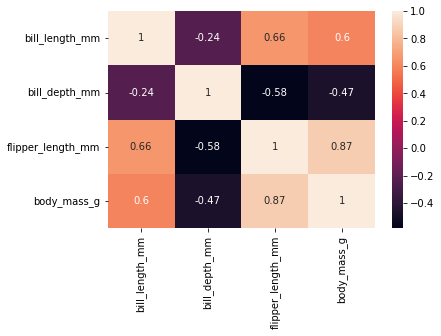

In [8]:
sns.heatmap(corr_mat, annot = True);

Палитра, выбранная по умолчанию, не совсем подходит для задачи визуализации коэффициентов корреляции: по идее, ячейки со значениями, близкими по модулю к 0, должны быть «бледными» (слабая связь), а ячейки со значениями, близкими по модулю к 1, должны быть «яркими» (сильная связь). 

Выберем палитру `RdBu` (от *Reds-Blues*) из набора расходящихся (*diverging*) палитр [здесь](https://matplotlib.org/stable/users/explain/colors/colormaps.html) – расходящиеся палитры как раз в середине содержат белый цвет, который в данном случае должен соответствовать значениям около 0:

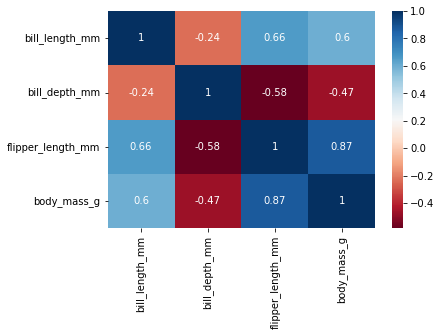

In [9]:
sns.heatmap(corr_mat, annot = True, cmap = "RdBu");

Выглядит довольно неплохо: видно, между какими парами показателей корреляция положительна, а между какими – отрицательна, сила связи тоже считывается за счет оттенков. 

Однако тепловые карты недолюбливают из-за того, что интенсивность цвета часто вводит в заблуждение – если все коэффициенты корреляции довольно низкие по модулю, все равно самым большим значениям среди имеющихся будет соответствовать самый насыщенный/темный цвет. 

В данном случае такая проблема тоже есть. Коэффициент (–0.58) означает среднюю силу связи, однако цвет на графике самый темный среди оттенков красного, что создает ложное впечатление того, связь сильная. Чтобы преодолеть этот недостаток, зафиксируем минимальное и максимальное значение (-1 и 1), чтобы цвета «растягивались» в градиенте более разумным образом:

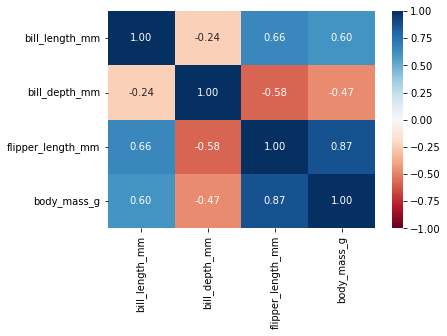

In [10]:
# заодно для единообразия зафиксируем формат (fmt) 
# значений в ячейках – отображение с двумя знаками после точки

sns.heatmap(corr_mat, annot = True, cmap = "RdBu", 
           vmin = -1, vmax = 1, fmt = ".2f");

Такая тепловая карта выглядит более корректно.

**Дополнительно.** Если хочется получить график, который не стыдно показать людям, можно импортировать `matplotlib` и настроить параметры самого изображения для последующего экспорта в файл.

In [11]:
from matplotlib import pyplot as plt

Предварительно создадим список с названиями переменных (без всяких `_`), чтобы записать их по строкам и столбцам:

In [12]:
var_names = ["Bill length", "Bill depth", 
             "Flipper length", "Body mass"]

В `figure()` настроим разрешение и размер, а в `heatmap()` добавим продвинутых настроек:

* делаем график квадратным: `square = True`;
* изменяем подписи с названиями переменными: `xticklabels` и `yticklabels`;

Так как функции `plt` и `sns` немного не согласованы, легенда (столбик с рястяжкой цветов справа) по умолчанию будет больше самой тепловой карты. Чтобы этого избежать, можно поэкспериментировать с параметром `shrink` в перечне соответствующих настроек для легенды `cbar_kws` (от *color bar keywords*):

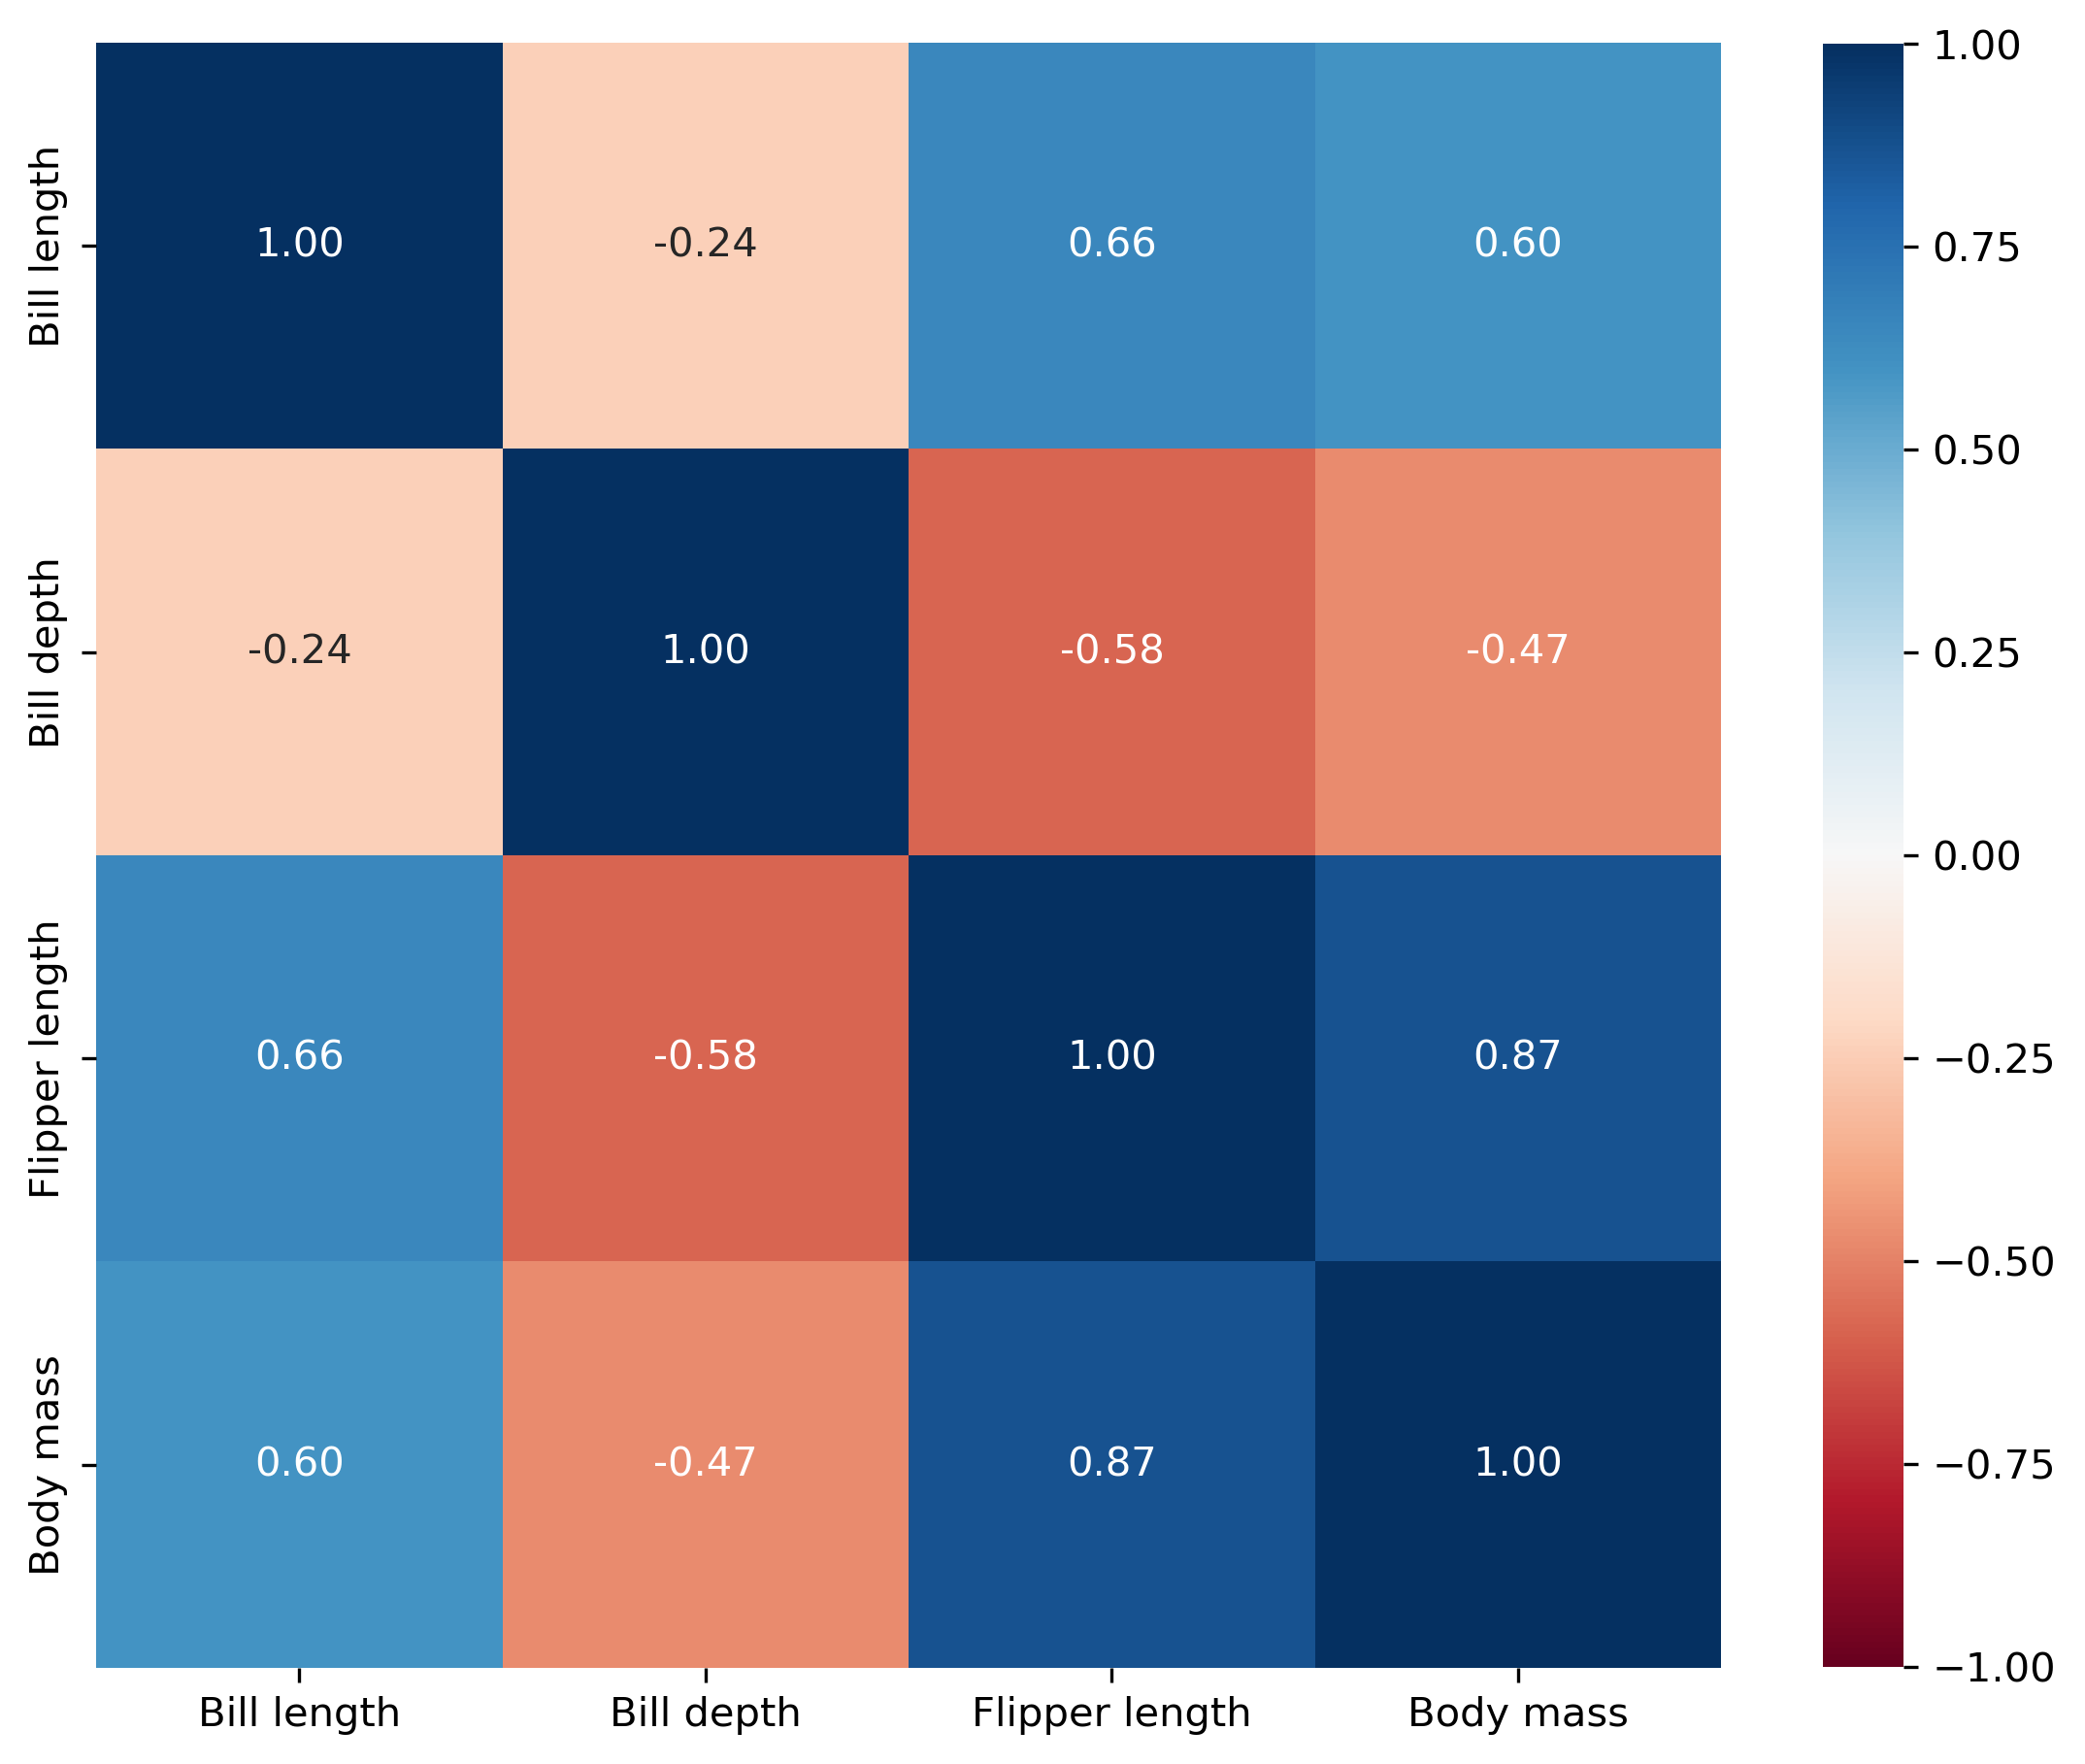

In [13]:
plt.figure(dpi = 300, figsize = (9, 9))
sns.heatmap(corr_mat, 
            annot = True, 
            cmap = "RdBu", 
            vmin = -1, 
            vmax = 1, 
            fmt = ".2f", 
            square = True, 
            xticklabels = var_names, 
            yticklabels = var_names, 
            cbar_kws = {"shrink": 0.82});

# выгружаем в файл

plt.savefig("heatmap_peng.png")

Осталось надеяться, что мы своей красивой тепловой картой не ускорили глобальное потепление и не спровоцировали панику у пингвинов :)

### Коэффициенты корреляции и проверка гипотез

Если нам необходимо не только получить коэффициент корреляции Пирсона/Спирмена, но еще и проверить, является ли он статистически значимым, потребуется модуль `stats` из библиотеки `scipy`:

In [14]:
from scipy import stats

**Важно.** Перед использованием функций `pearsonr()` и `spearmanr()` нужно избавиться от пропущенных значений (удалить или заполнить), иначе будет возвращена ошибка `ValueError: array must not contain infs or NaNs`. 

Проверим наличие пропусков в `pen_num`:

In [15]:
pen_num.isna().sum()

bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
dtype: int64

Пропусков мало, просто избавимся от них:

In [16]:
pen2 = pen_num.dropna()

Вычислим коэффициент Пирсона между длиной и глубиной клюва и проверим $H_0: R = 0$ об отсутствии линейной связи между этими показателями:

In [17]:
stats.pearsonr(pen2["bill_length_mm"], 
               pen2["bill_depth_mm"])

PearsonRResult(statistic=-0.2350528703555327, pvalue=1.119662196137322e-05)

Коэффициент Пирсона отрицательный, не очень высокий по модулю ($-0.235$), связь обратная и слабая. Однако нельзя сказать, что линейная связь отсутствует, p-value очень мало ($1.12 \times 10^{-5} \approx 0$), поэтому на 5%-ном уровне значимости нулевую гипотезу отвергаем. Связь слабая, но статистически значимая.

С коэффициентом Спирмена похожая история:

In [18]:
stats.spearmanr(pen2["bill_length_mm"], 
                pen2["bill_depth_mm"])

SignificanceResult(statistic=-0.22174915179457863, pvalue=3.511539739648998e-05)

### Критерий хи-квадрат и тепловая карта

Перейдем к качественным показателям и построим таблицу сопряженности *остров обитания пингвинов* vs *вид пингвинов*. Воспользуемся функцией `crosstab()` (от *cross tabulation* – перекрестная или сводная таблица): 

In [19]:
tab = pd.crosstab(pen["island"], 
                  pen["species"])
tab

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


В данном случае и так видно, что связь между признаками должна быть – некоторые виды пингвинов встречаются только на определенных островах. Покажем это с помощью формального критерия хи-квадрат для таблиц сопряженности. Для этого из модуля `stats` библиотеки `scipy` вызовем функцию `chi2_contingency()` и применим ее к таблице сопряженности:

In [20]:
from scipy import stats

In [21]:
print(stats.chi2_contingency(tab))

Chi2ContingencyResult(statistic=299.55032743148195, pvalue=1.3545738297192517e-63, dof=4, expected_freq=array([[74.23255814, 33.20930233, 60.55813953],
       [54.79069767, 24.51162791, 44.69767442],
       [22.97674419, 10.27906977, 18.74418605]]))


Итак:

* $H_0$: признаки независимы;
* наблюдаемое значение статистики $\chi^2$ равно 299.55;
* p-value примерно 0 ($1.35 \times 10^{-63}$);
* число степеней свободы 4, в `tab` три строки и три столбца, поэтому $\text{df} = (3-1)\cdot(3-1)$.

Раз p-value почти 0, $H_0$ отвергается на любом разумном уровне значимости, поэтому признаки не независимы, есть зависимость между ареалом обитания и видом пингвинов. 

Последний результат – частоты, которые ожидались бы в таблице `tab` при условии, что $H_0$ верна, то есть, если бы признаки действительно были независимы. Чем сильнее различия значений в `tab` и в `expected_freq`, тем больше шансов, что нулевая гипотеза о независимости будет отвергнута.

**Дополнительно.** Если для нас важно не просто зафиксировать факт отвержения/не отвержения нулевой гипотезы, а изучить, за счет каких значений достигаются наибольшие и наименьшие различия между наблюдаемыми и ожидаемыми частотами, имеет смысл вычислить стандартизированные остатки:

$$
\frac{n_{ij}^{набл} - n_{ij}^{ожид}}{\sqrt{n_{ij}^{ожид}}},
$$

где $n_{ij}$ – это значение частоты в таблице сопряженности на пересечении строки $i$ и $j$. 

Заберем массив с ожидаемыми частотами – это последний элемент в результате `chi2_contingency(tab)` – и превратим его в датафрейм:

In [22]:
res = stats.chi2_contingency(tab)
expected = pd.DataFrame(res[-1])
expected

,0,1,2
0,74.232558,33.209302,60.558140
1,54.790698,24.511628,44.697674
2,22.976744,10.279070,18.744186


Теперь, поэлементно вычитая из `tab` значения `expected` и также поэлементно деля на квадратный корень из `expected`, мы получим стандартизированные остатки для всех ячеек. Попробуем:

In [23]:
(tab - expected) / expected ** 0.5

,0,1,2,Adelie,Chinstrap,Gentoo
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
Biscoe,NaN,NaN,NaN,NaN,NaN,NaN
Dream,NaN,NaN,NaN,NaN,NaN,NaN
Torgersen,NaN,NaN,NaN,NaN,NaN,NaN


Получилось что-то странное, хотя вообще из одного датафрейма можно вычитать другой датафрейм такой же размерности. Так в чем проблема? В том, что для корректных поэлементных операций у датафреймов должны быть одинаковые названия столбцов и строк. Переименуем названия в `expected`:

In [24]:
expected.columns = tab.columns
expected.index = tab.index

Теперь все хорошо:

In [25]:
resid_std = (tab - expected) / expected ** 0.5
resid_std

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,-3.508954,-5.762751,8.152478
Dream,0.163373,8.783894,-6.685632
Torgersen,6.054829,-3.206099,-4.329456


Считается, что значения стандартизованных остатков больше 2 или 3 по модулю (вспоминаем типичные и нетипичные значения для стандартного нормального распределения) свидетельствуют о сильном и статистически значимом расхождении между наблюдаемыми и ожидаемыми частотами. 

Исходные таблицы сопряженности и связанные с ними стандартизованные остатки иногда визуализируют с помощью **мозаичных графиков** ([пример 1](https://en.wikipedia.org/wiki/Mosaic_plot), [пример 2](https://stats.stackexchange.com/questions/147863/how-to-interpret-the-residual-colors-on-a-mosaic-plot)), однако из-за того, что эти графики весьма специфические, их заменяют на **тепловые карты**. Построим тепловую карту для остатков в `resid_std`:

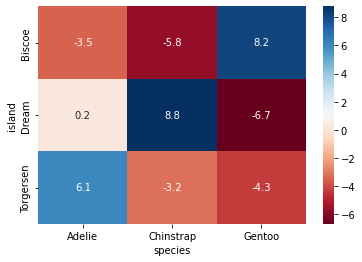

In [26]:
sns.heatmap(resid_std, annot = True, 
            fmt = ".1f", cmap = "RdBu");

По такой карте видно, что различия между наблюдаемыми и ожидаемыми частотами большие во всех случаях, кроме одного. Так, например, на острове Мечты (*island Dream*) пингвинов антарктического вида (*Chinstrap*) сильно больше, чем ожидалось бы в случае, если географическое распространение пингвинов не зависело бы от их вида – остаток положительный и большой по модулю. А на островах Бискоу (*Biscoe*) пингвинов этого вида, наоборот, сильно меньше, чем в случае, если бы пингвины разных видов распределялись по всем островам примерно равномерно – остаток отрицательный и тоже намаленький по модулю.